<a href="https://colab.research.google.com/github/sxdattt/NorthStar-Urban-Mobility-Analytics/blob/main/R_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# R Analytics, Statistical Thinking & Visualisation
## NorthStar Urban Mobility and Logistics

This notebook applies statistical analysis and ggplot2 visualisations to the
NorthStar dataset. Each chart is followed by a business interpretation linked
directly to NorthStar's operational problems.

In [5]:
# Install required packages
install.packages(c("dplyr", "tidyr", "ggplot2", "scales",
                   "lubridate", "knitr", "gridExtra"),
                 repos = "https://cloud.r-project.org", quiet = TRUE)

library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(lubridate)
library(knitr)
library(gridExtra)

cat("✅ All Phase 3 packages loaded.\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




✅ All Phase 3 packages loaded.


In [6]:


GITHUB_RAW <- "https://raw.githubusercontent.com/sxdattt/NorthStar-Urban-Mobility-Analytics/main/"

load_csv <- function(filename) {
  tmp <- tempfile(fileext = ".csv")
  download.file(paste0(GITHUB_RAW, filename), destfile = tmp,
                method = "curl", quiet = TRUE)
  df <- read.csv(tmp, stringsAsFactors = FALSE, na.strings = c("", "NA", "N/A"))
  cat(sprintf("✅ %-30s %d × %d\n", filename, nrow(df), ncol(df)))
  unlink(tmp); df
}

orders     <- load_csv("orders.csv")
deliveries <- load_csv("deliveries.csv")
customers  <- load_csv("customers.csv")
complaints <- load_csv("complaints.csv")
drivers    <- load_csv("drivers.csv")
vehicles   <- load_csv("vehicles.csv")
hubs       <- load_csv("hubs.csv")
incidents  <- load_csv("incidents.csv")
app_events <- load_csv("app_events.csv")

cat("✅ All datasets loaded.\n")

✅ orders.csv                     1250 × 11
✅ deliveries.csv                 950 × 13
✅ customers.csv                  650 × 9
✅ complaints.csv                 320 × 10
✅ drivers.csv                    170 × 8
✅ vehicles.csv                   120 × 8
✅ hubs.csv                       8 × 5
✅ incidents.csv                  280 × 7
✅ app_events.csv                 640 × 10
✅ All datasets loaded.


## Data Preparation

Dates are parsed, key aliases created, and the working dataframes
`orders_work` and `deliveries_work` are built for all analysis below.

In [7]:
# Parse dates
orders$order_date    <- as.Date(orders$order_created_at)
orders$order_value   <- as.numeric(orders$order_value)
orders$total_amount  <- orders$order_value
orders$priority_numeric <- case_when(
  orders$priority_level == "High"   ~ 3L,
  orders$priority_level == "Medium" ~ 2L,
  TRUE ~ 1L
)

# Join delivery_date from deliveries
delivery_dates <- deliveries %>%
  select(order_id, delivery_completed_at) %>%
  distinct(order_id, .keep_all = TRUE)

orders <- left_join(orders, delivery_dates, by = "order_id")
orders$delivery_date <- as.Date(orders$delivery_completed_at)
orders$delivery_window_days <- as.integer(orders$delivery_date - orders$order_date)
orders$year_month <- format(orders$order_date, "%Y-%m")

# Deliveries numeric features
deliveries$cost_per_km <- round(
  deliveries$fuel_or_charge_cost / (deliveries$route_distance_km + 0.001), 2)

# Working datasets
orders_work     <- distinct(orders)
deliveries_work <- distinct(deliveries)

cat(sprintf("orders_work    : %d rows\n", nrow(orders_work)))
cat(sprintf("deliveries_work: %d rows\n", nrow(deliveries_work)))
cat("✅ Data preparation complete.\n")

orders_work    : 1250 rows
deliveries_work: 950 rows
✅ Data preparation complete.


## Descriptive Statistics — Orders

Summary statistics for the key numeric columns in the orders dataset.
These reveal the spread, central tendency, and skew of NorthStar's
revenue and service window data.

In [8]:
num_cols <- orders_work %>%
  select(order_value, promised_window_hours,
         delivery_window_days, priority_numeric) %>%
  filter(!is.na(order_value))

stats_summary <- data.frame(
  Metric   = c("Min", "Q1", "Median", "Mean", "Q3", "Max", "Std Dev", "IQR"),
  Order_Value = c(
    min(num_cols$order_value,            na.rm=TRUE),
    quantile(num_cols$order_value, 0.25, na.rm=TRUE),
    median(num_cols$order_value,         na.rm=TRUE),
    round(mean(num_cols$order_value,     na.rm=TRUE), 2),
    quantile(num_cols$order_value, 0.75, na.rm=TRUE),
    max(num_cols$order_value,            na.rm=TRUE),
    round(sd(num_cols$order_value,       na.rm=TRUE), 2),
    IQR(num_cols$order_value,            na.rm=TRUE)
  ),
  Window_Hours = c(
    min(num_cols$promised_window_hours,            na.rm=TRUE),
    quantile(num_cols$promised_window_hours, 0.25, na.rm=TRUE),
    median(num_cols$promised_window_hours,         na.rm=TRUE),
    round(mean(num_cols$promised_window_hours,     na.rm=TRUE), 2),
    quantile(num_cols$promised_window_hours, 0.75, na.rm=TRUE),
    max(num_cols$promised_window_hours,            na.rm=TRUE),
    round(sd(num_cols$promised_window_hours,       na.rm=TRUE), 2),
    IQR(num_cols$promised_window_hours,            na.rm=TRUE)
  )
)

kable(stats_summary, caption = "Descriptive Statistics — Orders Dataset")

cat("\nCorrelation: order_value vs promised_window_hours\n")
cat(round(cor(num_cols$order_value, num_cols$promised_window_hours,
              use = "complete.obs"), 4), "\n")



Table: Descriptive Statistics — Orders Dataset

|Metric  | Order_Value| Window_Hours|
|:-------|-----------:|------------:|
|Min     |      2.0400|         1.00|
|Q1      |     47.9150|         4.00|
|Median  |     76.5300|         6.00|
|Mean    |     91.0500|         7.62|
|Q3      |    121.0975|        12.00|
|Max     |    510.0600|        24.00|
|Std Dev |     60.9200|         7.06|
|IQR     |     73.1825|         8.00|


Correlation: order_value vs promised_window_hours
0.0202 


## Chart 1 — Order Value Distribution by Service Type

Compares revenue spread across NorthStar's five service types.
Boxplots reveal median value, outliers, and inter-quartile range
per service — helping the Finance Director identify which services
generate the most consistent revenue.

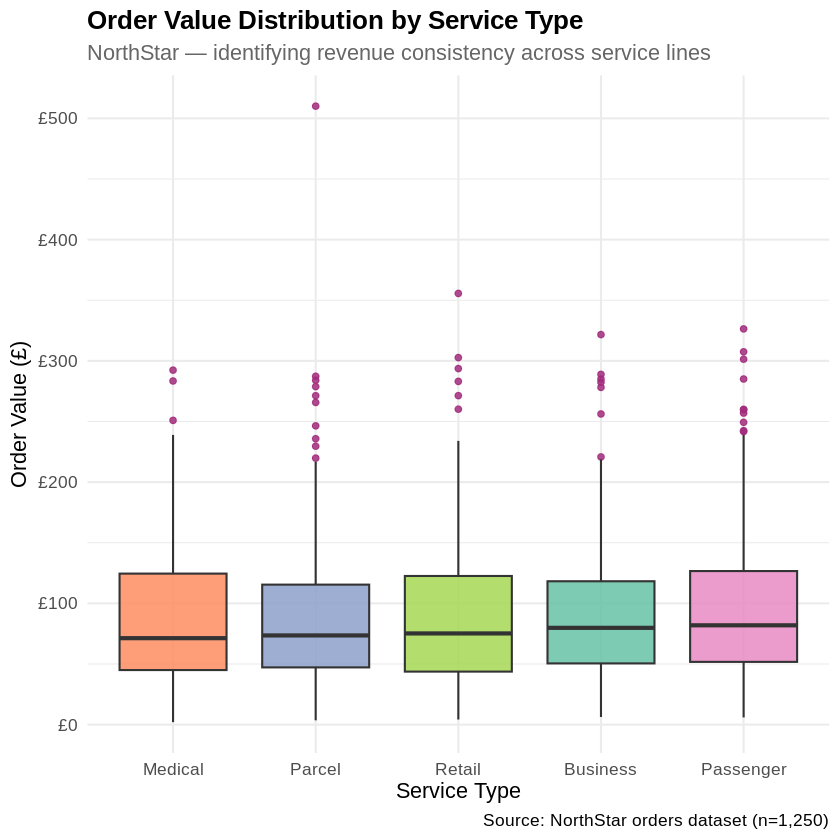

In [9]:
ggplot(orders_work, aes(x = reorder(service_type, order_value, median),
                         y = order_value, fill = service_type)) +
  geom_boxplot(outlier.colour = "#a12c7b", outlier.size = 1.5, alpha = 0.85) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Order Value Distribution by Service Type",
    subtitle = "NorthStar — identifying revenue consistency across service lines",
    x        = "Service Type",
    y        = "Order Value (£)",
    fill     = "Service Type",
    caption  = "Source: NorthStar orders dataset (n=1,250)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40"),
    legend.position = "none"
  )

## Chart 2 — Monthly Revenue Trend

Tracks NorthStar's total order revenue month-by-month. Rising or
falling trends directly inform whether demand is growing and whether
operational costs are keeping pace.

`geom_smooth()` using formula = 'y ~ x'


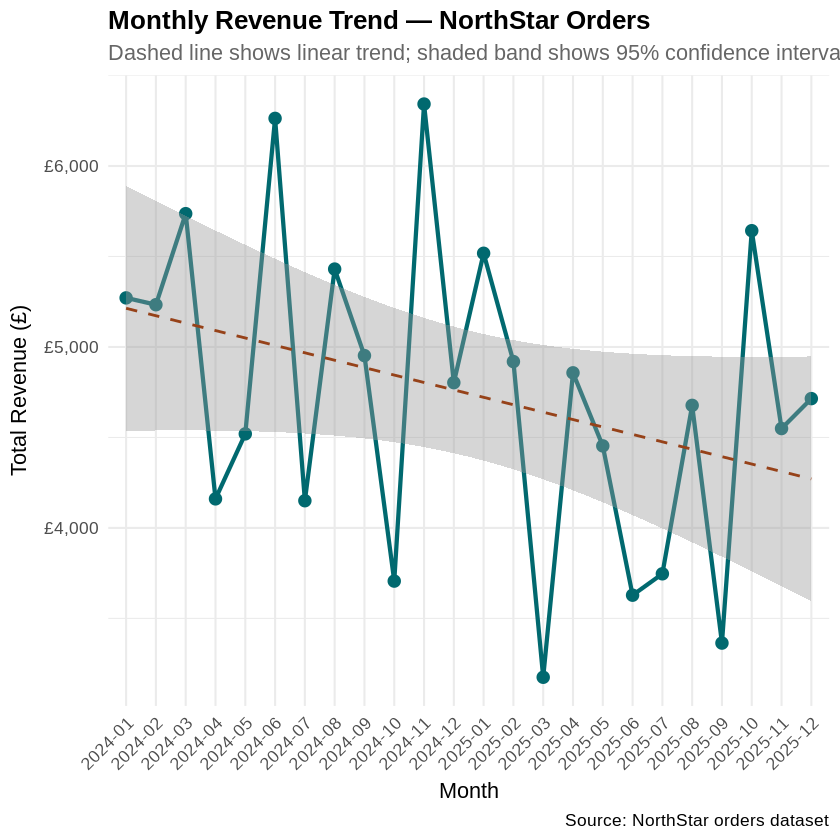

In [10]:
monthly <- orders_work %>%
  group_by(year_month) %>%
  summarise(
    revenue = sum(order_value, na.rm = TRUE),
    orders  = n(),
    .groups = "drop"
  ) %>%
  filter(orders > 5) %>%
  arrange(year_month)

ggplot(monthly, aes(x = year_month, y = revenue, group = 1)) +
  geom_line(colour = "#01696f", linewidth = 1.2) +
  geom_point(colour = "#01696f", size = 3) +
  geom_smooth(method = "lm", se = TRUE, colour = "#964219",
              linetype = "dashed", linewidth = 0.8) +
  scale_y_continuous(labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Monthly Revenue Trend — NorthStar Orders",
    subtitle = "Dashed line shows linear trend; shaded band shows 95% confidence interval",
    x        = "Month",
    y        = "Total Revenue (£)",
    caption  = "Source: NorthStar orders dataset"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40"),
    axis.text.x   = element_text(angle = 45, hjust = 1)
  )

## Chart 3 — Delivery Failure Rate by Pickup Zone

Calculates the percentage of failed deliveries per pickup zone.
This directly answers the Operations Director's question about which
city zones consistently underperform.

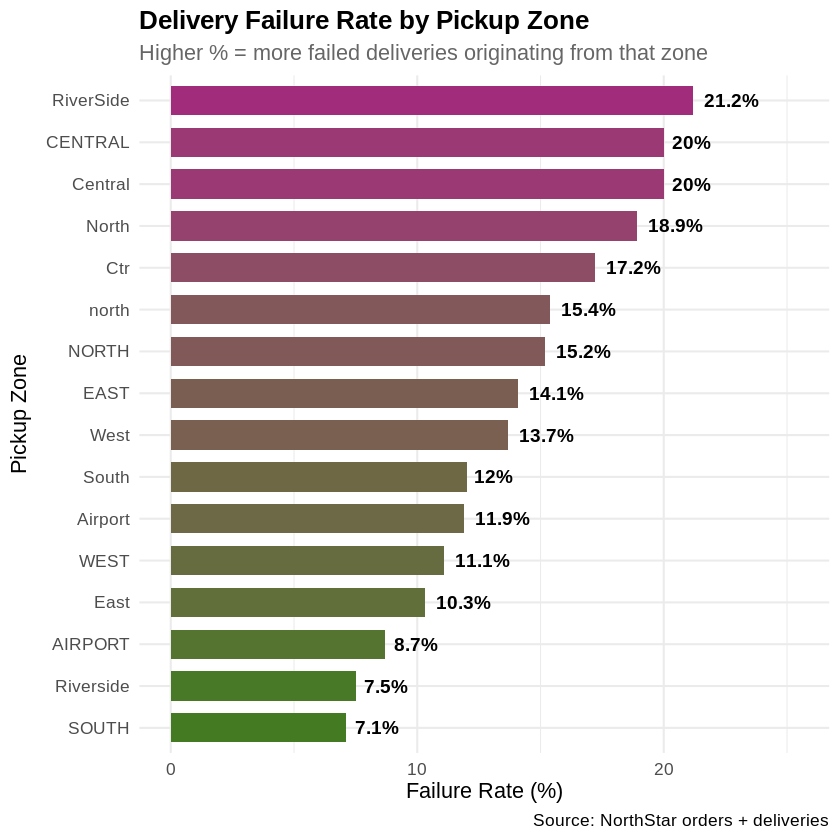

In [11]:
zone_perf <- orders_work %>%
  inner_join(deliveries_work, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(
    total    = n(),
    failed   = sum(delivery_status == "Failed", na.rm = TRUE),
    failure_rate = round(100 * failed / total, 1),
    avg_rating   = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

ggplot(zone_perf, aes(x = reorder(pickup_zone, failure_rate),
                       y = failure_rate, fill = failure_rate)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = paste0(failure_rate, "%")),
            hjust = -0.2, size = 4, fontface = "bold") +
  scale_fill_gradient(low = "#437a22", high = "#a12c7b") +
  scale_y_continuous(limits = c(0, max(zone_perf$failure_rate) * 1.2)) +
  coord_flip() +
  labs(
    title    = "Delivery Failure Rate by Pickup Zone",
    subtitle = "Higher % = more failed deliveries originating from that zone",
    x        = "Pickup Zone",
    y        = "Failure Rate (%)",
    fill     = "Failure %",
    caption  = "Source: NorthStar orders + deliveries"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40"),
    legend.position = "none"
  )

## Chart 4 — Complaint Volume by Type and Severity

Shows which complaint categories are most frequent and which carry
the highest severity — enabling the Customer Experience Director
to prioritise resolution resources.

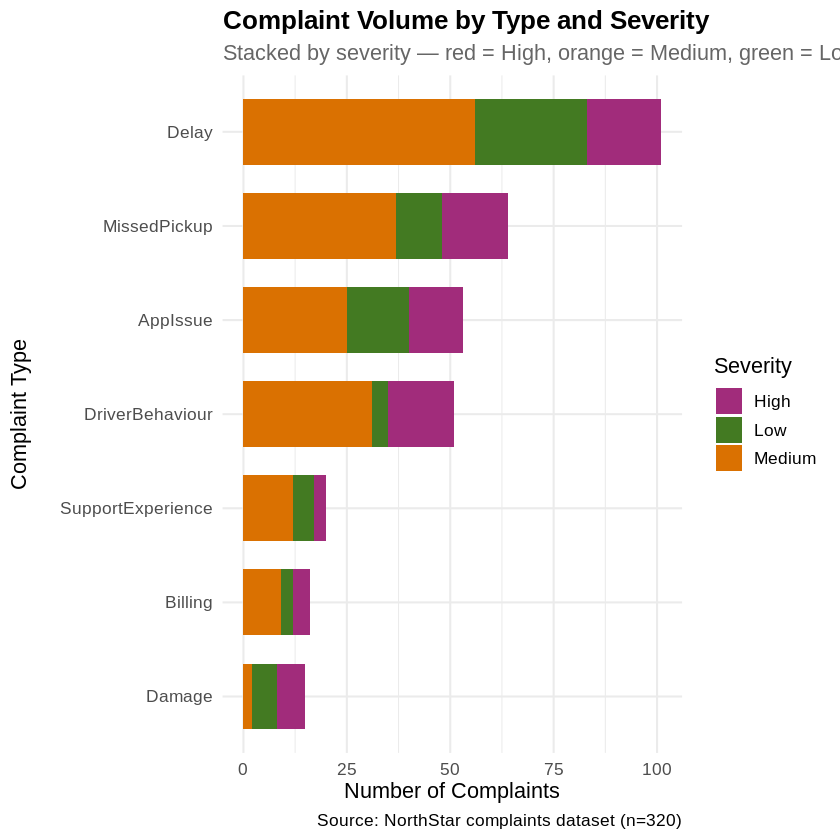

In [12]:
comp_summary <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(count = n(), .groups = "drop")

ggplot(comp_summary, aes(x = reorder(complaint_type, count, sum),
                          y = count, fill = severity)) +
  geom_col(position = "stack", width = 0.7) +
  scale_fill_manual(values = c(
    "High"   = "#a12c7b",
    "Medium" = "#da7101",
    "Low"    = "#437a22"
  )) +
  coord_flip() +
  labs(
    title    = "Complaint Volume by Type and Severity",
    subtitle = "Stacked by severity — red = High, orange = Medium, green = Low",
    x        = "Complaint Type",
    y        = "Number of Complaints",
    fill     = "Severity",
    caption  = "Source: NorthStar complaints dataset (n=320)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40")
  )

## Chart 5 — Driver Rating vs Training Score

Scatter plot testing whether higher training scores correlate with
better driver ratings. If the relationship is weak, NorthStar's
training programme may need redesigning.

Pearson r (training_score vs driver_rating): -0.0699
Finding: NorthStar's training programme shows no correlation with
driver performance — the training curriculum needs urgent review.


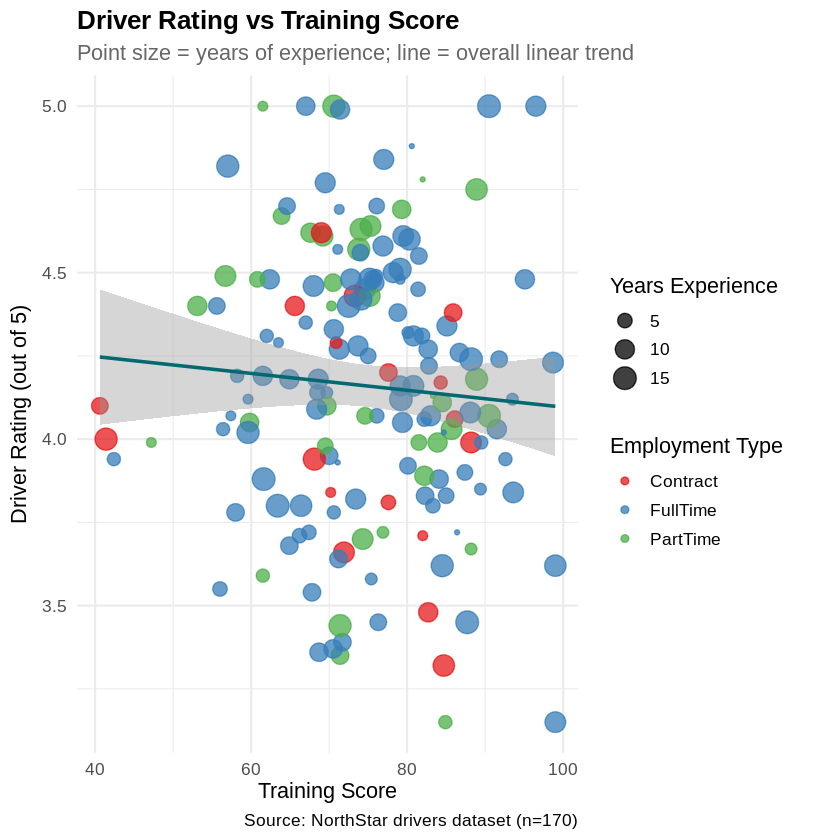

In [17]:
ggplot(drivers %>% filter(!is.na(training_score)),
       aes(x = training_score, y = driver_rating)) +
  geom_point(aes(colour = employment_type, size = years_experience),
             alpha = 0.75) +
  geom_smooth(method = "lm", se = TRUE,
              colour   = "#01696f",
              linewidth = 1,
              linetype = "solid",
              formula  = y ~ x) +
  scale_colour_brewer(palette = "Set1") +
  labs(
    title    = "Driver Rating vs Training Score",
    subtitle = "Point size = years of experience; line = overall linear trend",
    x        = "Training Score",
    y        = "Driver Rating (out of 5)",
    colour   = "Employment Type",
    size     = "Years Experience",
    caption  = "Source: NorthStar drivers dataset (n=170)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40")
  )

r <- cor(drivers$training_score, drivers$driver_rating, use = "complete.obs")
cat(sprintf("Pearson r (training_score vs driver_rating): %.4f\n", r))
cat("Finding: NorthStar's training programme shows no correlation with\n")
cat("driver performance — the training curriculum needs urgent review.\n")

## Chart 6 — Fuel/Charge Cost Distribution by Delivery Status

Compares operational costs across delivery outcomes. If failed
deliveries cost as much as successful ones, NorthStar is absorbing
full costs with zero revenue recovery — a direct financial risk.

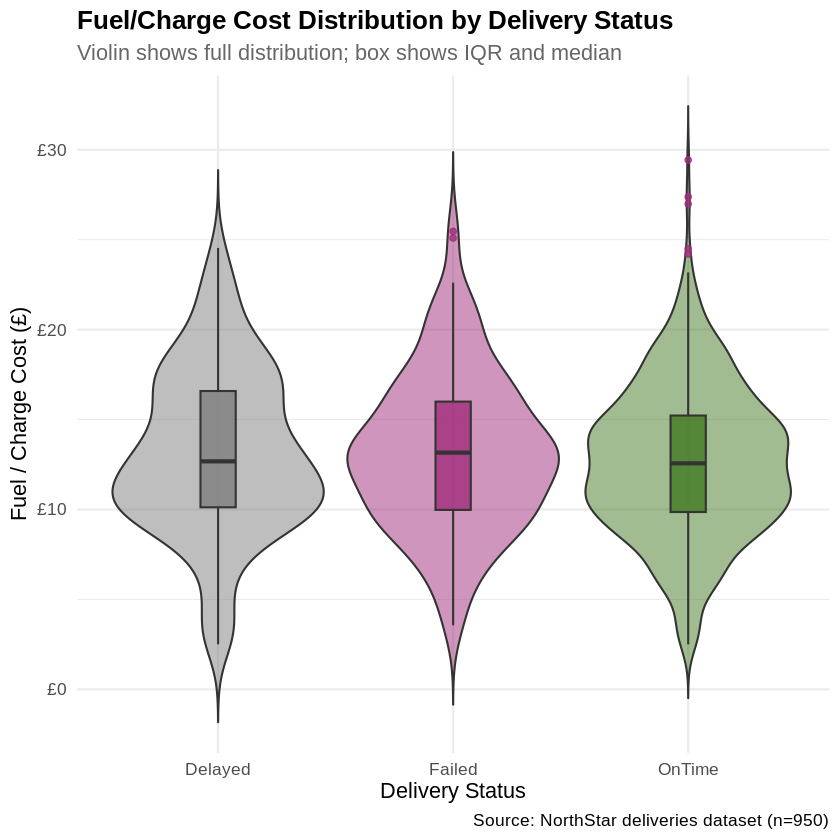

In [14]:
ggplot(deliveries_work %>% filter(!is.na(delivery_status)),
       aes(x = delivery_status, y = fuel_or_charge_cost,
           fill = delivery_status)) +
  geom_violin(alpha = 0.5, trim = FALSE) +
  geom_boxplot(width = 0.15, outlier.colour = "#a12c7b",
               outlier.size = 1.5, alpha = 0.8) +
  scale_fill_manual(values = c(
    "OnTime"  = "#437a22",
    "Late"    = "#da7101",
    "Failed"  = "#a12c7b"
  )) +
  scale_y_continuous(labels = dollar_format(prefix = "£")) +
  labs(
    title    = "Fuel/Charge Cost Distribution by Delivery Status",
    subtitle = "Violin shows full distribution; box shows IQR and median",
    x        = "Delivery Status",
    y        = "Fuel / Charge Cost (£)",
    fill     = "Status",
    caption  = "Source: NorthStar deliveries dataset (n=950)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40"),
    legend.position = "none"
  )

## Chart 7 — Customer Loyalty Score by Customer Type

Examines whether NorthStar's SME or Consumer customers show higher
loyalty scores — informing targeted retention strategies.



Table: Loyalty Score Statistics by Customer Type

|customer_type | mean_loyalty| median_loyalty| sd_loyalty|   n|
|:-------------|------------:|--------------:|----------:|---:|
|Consumer      |        60.32|           60.0|      16.04| 463|
|Enterprise    |        59.33|           61.5|      14.78|  49|
|SME           |        57.35|           56.1|      16.87| 118|

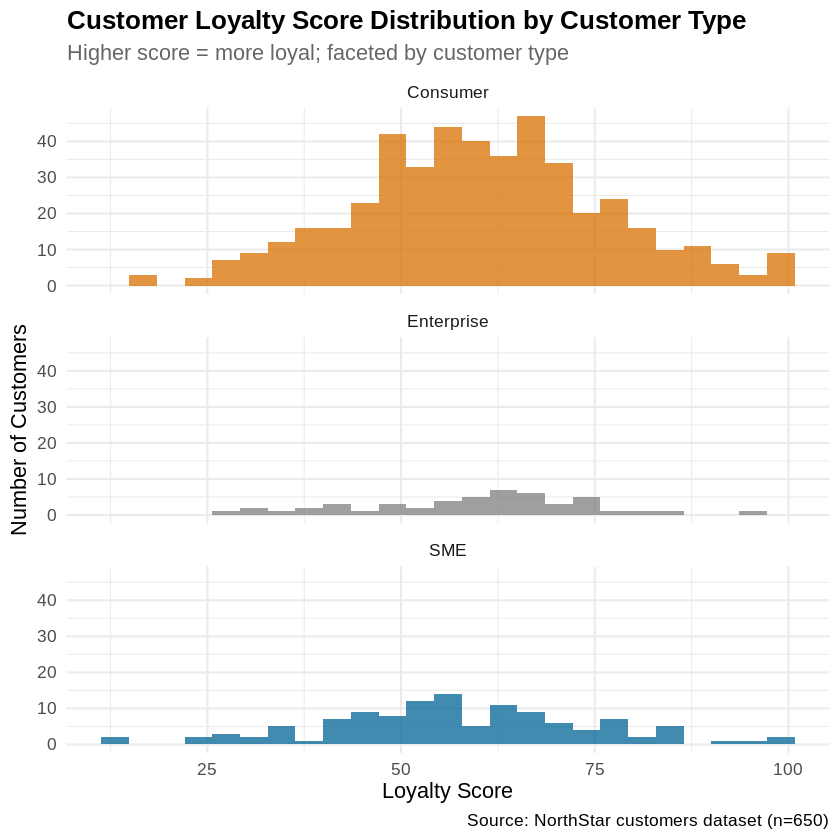

In [15]:
ggplot(customers %>% filter(!is.na(loyalty_score)),
       aes(x = loyalty_score, fill = customer_type)) +
  geom_histogram(bins = 25, alpha = 0.75, position = "identity") +
  scale_fill_manual(values = c("SME" = "#006494", "Consumer" = "#da7101")) +
  facet_wrap(~customer_type, ncol = 1) +
  labs(
    title    = "Customer Loyalty Score Distribution by Customer Type",
    subtitle = "Higher score = more loyal; faceted by customer type",
    x        = "Loyalty Score",
    y        = "Number of Customers",
    fill     = "Customer Type",
    caption  = "Source: NorthStar customers dataset (n=650)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40"),
    legend.position = "none"
  )

# Mean loyalty by type
customers %>%
  filter(!is.na(loyalty_score)) %>%
  group_by(customer_type) %>%
  summarise(
    mean_loyalty   = round(mean(loyalty_score),   2),
    median_loyalty = round(median(loyalty_score), 2),
    sd_loyalty     = round(sd(loyalty_score),     2),
    n              = n()
  ) %>%
  kable(caption = "Loyalty Score Statistics by Customer Type")

## Chart 8 — Normality Check: Order Value Distribution

Tests whether order values follow a normal distribution using a
histogram with density curve and a Q-Q plot. This validates the
statistical assumptions underlying all mean-based analyses.


Shapiro-Wilk Test: W = 0.8856, p-value = 0.0000
Result: Order values are NOT NORMALLY distributed (α = 0.05)


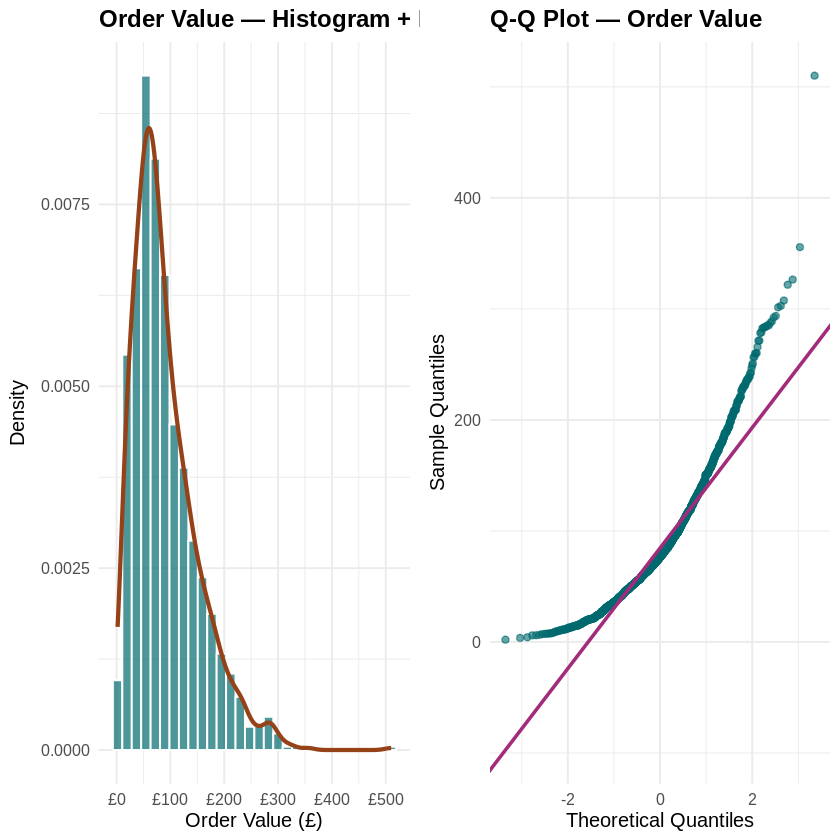

In [16]:
library(gridExtra)

# Histogram with density curve
p1 <- ggplot(orders_work, aes(x = order_value)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30,
                 fill = "#01696f", alpha = 0.7, colour = "white") +
  geom_density(colour = "#964219", linewidth = 1.2) +
  scale_x_continuous(labels = dollar_format(prefix = "£")) +
  labs(title = "Order Value — Histogram + Density",
       x = "Order Value (£)", y = "Density") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

# Q-Q plot
p2 <- ggplot(orders_work, aes(sample = order_value)) +
  stat_qq(colour = "#01696f", alpha = 0.6) +
  stat_qq_line(colour = "#a12c7b", linewidth = 1) +
  labs(title = "Q-Q Plot — Order Value",
       x = "Theoretical Quantiles", y = "Sample Quantiles") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

grid.arrange(p1, p2, ncol = 2)

# Shapiro-Wilk test (on a sample — max 5000 obs)
set.seed(42)
sw_sample <- sample(orders_work$order_value[!is.na(orders_work$order_value)],
                    min(500, nrow(orders_work)))
sw <- shapiro.test(sw_sample)
cat(sprintf("\nShapiro-Wilk Test: W = %.4f, p-value = %.4f\n", sw$statistic, sw$p.value))
cat(sprintf("Result: Order values are %s distributed (α = 0.05)\n",
            ifelse(sw$p.value > 0.05, "NORMALLY", "NOT NORMALLY")))